# Experiment 1: Cross-Channel Ambiguity Calibration


Verifies that the TEMPO v1.1 jointly calibrated parameters
$\sigma = 0.838 \times T_u$ and $T_{\text{thresh}} = 2.17 \times T_u$
produce balanced cross-channel misclassification within the 8–12% target range.

## Protocol

For each $\sigma$ in a sweep from $0$ to $1.5 \times T_u$ (steps of $0.05 \times T_u$):
1. Generate **100,000 marks** (50,000 dots + 50,000 dashes) at 20 WPM
2. Apply full weighting ($\omega \sim \mathcal{U}[0.8, 1.3]$) and
   dash-ratio variation ($r \sim \mathcal{U}[2.5, 4.5]$), sampled independently per mark
3. Count marks where the channel assigned by the threshold
   ($T_{\text{thresh}} = 2.17 \times T_u$) does not match the intended dot/dash identity

The protocol values are then verified at high precision ($N = 500{,}000$ marks)
with 95% Wilson confidence intervals.

No SNN training is required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SEED = 42
rng  = np.random.default_rng(SEED)

print(f"NumPy {np.__version__},  seed={SEED}")

NumPy 1.26.3,  seed=42


## Protocol Parameters

In [2]:
# Transmission
WPM    = 20
T_U    = 1200.0 / WPM           # 60 ms at 20 WPM

# TEMPO v1.1 calibrated values
SIGMA_FRAC = 0.838              # critical noise level
T_THRESH   = 2.17 * T_U        # channel decision boundary

# Noise distributions
OMEGA_LO, OMEGA_HI = 0.8, 1.3
R_LO,     R_HI     = 2.5, 4.5

# Simulation sizes
N_SWEEP  = 100_000              # marks per sigma value in sweep
N_VERIFY = 500_000              # marks for high-precision verification

# Target calibration range
CALIB_LO = 0.08
CALIB_HI = 0.12

print(f"T_u      = {T_U:.1f} ms")
print(f"T_thresh = {T_THRESH:.2f} ms  ({T_THRESH/T_U:.2f}·T_u)")
print(f"sigma    = {SIGMA_FRAC * T_U:.2f} ms  ({SIGMA_FRAC:.3f}·T_u)")
print(f"Target   : {CALIB_LO*100:.0f}–12% misclassification")

T_u      = 60.0 ms
T_thresh = 130.20 ms  (2.17·T_u)
sigma    = 50.28 ms  (0.838·T_u)
Target   : 8–12% misclassification


## Simulation Function

In [3]:
def simulate_marks(n_dots, n_dashes, sigma, t_u, t_thresh, rng):
    """
    Generate dot and dash marks under TEMPO v1.1 stochastic corruption
    and count cross-channel misclassifications.

    omega and r are sampled independently per mark (each mark treated as
    its own word scope, appropriate for isolated mark-level statistics).

    Returns dict with error rates, raw duration arrays, and clipping fractions.
    Clipping fraction: fraction of marks whose pre-clip duration was below
    0.1 × T_u (the minimum-duration floor from TEMPO v1.1 Algorithm 1).
    Note: every clipped dash is guaranteed to be a misclassification (its
    floored duration 0.1·T_u << T_thresh, so it is always assigned to DOT_CH).
    """
    omega_dot  = rng.uniform(OMEGA_LO, OMEGA_HI, size=n_dots)
    omega_dash = rng.uniform(OMEGA_LO, OMEGA_HI, size=n_dashes)
    r_dash     = rng.uniform(R_LO,     R_HI,     size=n_dashes)

    t_dot_w  = 1.0    * t_u * omega_dot
    t_dash_w = r_dash * t_u * omega_dash

    if sigma > 0:
        t_dot_f  = t_dot_w  + rng.normal(0, sigma, size=n_dots)
        t_dash_f = t_dash_w + rng.normal(0, sigma, size=n_dashes)
    else:
        t_dot_f  = t_dot_w.copy()
        t_dash_f = t_dash_w.copy()

    clip         = 0.1 * t_u
    dot_clipped  = int((t_dot_f  < clip).sum())
    dash_clipped = int((t_dash_f < clip).sum())
    t_dot_f      = np.maximum(t_dot_f,  clip)
    t_dash_f     = np.maximum(t_dash_f, clip)

    dot_miscl  = t_dot_f  >= t_thresh   # dot assigned to DASH_CH
    dash_miscl = t_dash_f <  t_thresh   # dash assigned to DOT_CH

    return {
        "dot_error_rate":     dot_miscl.mean(),
        "dash_error_rate":    dash_miscl.mean(),
        "overall_error_rate": (dot_miscl.sum() + dash_miscl.sum()) / (n_dots + n_dashes),
        "dot_durations":      t_dot_f,
        "dash_durations":     t_dash_f,
        "dot_clip_frac":      dot_clipped  / n_dots,
        "dash_clip_frac":     dash_clipped / n_dashes,
    }

## Sigma Sweep (0 to 1.5 × T_u)

Sweeps $\sigma$ from 0 to $1.5 \times T_u$ at resolution $0.05 \times T_u$
using the protocol threshold $T_{\text{thresh}} = 2.17 \times T_u$.
Rows within the 8–12% band are marked.

In [4]:
SWEEP_FRACS = np.arange(0.0, 1.51, 0.05)

sweep = []
print(f"{'sigma/T_u':>9}  {'dot err':>8}  {'dash err':>9}  {'overall':>8}")
print("-" * 48)

for frac in SWEEP_FRACS:
    sigma = frac * T_U
    res   = simulate_marks(N_SWEEP // 2, N_SWEEP // 2, sigma, T_U, T_THRESH, rng)
    sweep.append({
        "sigma_frac":         frac,
        "sigma_ms":           sigma,
        "dot_error_rate":     res["dot_error_rate"],
        "dash_error_rate":    res["dash_error_rate"],
        "overall_error_rate": res["overall_error_rate"],
    })

    in_band  = CALIB_LO <= res["overall_error_rate"] <= CALIB_HI
    at_proto = abs(frac - SIGMA_FRAC) < 0.026
    if in_band and at_proto:
        marker = "  ← protocol value  IN BAND ✓"
    elif in_band:
        marker = "  ← IN BAND"
    else:
        marker = ""
    print(
        f"{frac:9.2f}  "
        f"{res['dot_error_rate']:8.4f}  "
        f"{res['dash_error_rate']:9.4f}  "
        f"{res['overall_error_rate']:8.4f}"
        f"{marker}"
    )

sigma/T_u   dot err   dash err   overall
------------------------------------------------
     0.00    0.0000     0.0066    0.0033
     0.05    0.0000     0.0074    0.0037
     0.10    0.0000     0.0089    0.0044
     0.15    0.0000     0.0115    0.0058
     0.20    0.0000     0.0158    0.0079
     0.25    0.0000     0.0187    0.0094
     0.30    0.0003     0.0235    0.0119
     0.35    0.0012     0.0286    0.0149
     0.40    0.0037     0.0340    0.0188
     0.45    0.0089     0.0395    0.0242
     0.50    0.0158     0.0450    0.0304
     0.55    0.0237     0.0538    0.0387
     0.60    0.0347     0.0590    0.0469
     0.65    0.0473     0.0661    0.0567
     0.70    0.0585     0.0726    0.0656
     0.75    0.0692     0.0826    0.0759
     0.80    0.0851     0.0887    0.0869  ← IN BAND
     0.85    0.0935     0.0952    0.0944  ← protocol value  IN BAND ✓
     0.90    0.1116     0.1026    0.1071  ← IN BAND
     0.95    0.1212     0.1110    0.1161  ← IN BAND
     1.00    0.1352     0.11

## Calibration Verification

High-precision run ($N = 500{,}000$ marks) at the protocol parameters
$\sigma = 0.838 \times T_u$, $T_{\text{thresh}} = 2.17 \times T_u$.
Reports 95% Wilson confidence intervals for each error rate.

In [5]:
def wilson_ci(p, n, z=1.96):
    lo = (p + z**2/(2*n) - z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)
    hi = (p + z**2/(2*n) + z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)
    return lo, hi


verify_rng = np.random.default_rng(SEED + 1)
sigma_ms   = SIGMA_FRAC * T_U
n_half     = N_VERIFY // 2

res = simulate_marks(n_half, n_half, sigma_ms, T_U, T_THRESH, verify_rng)

dot_rate  = res["dot_error_rate"]
dash_rate = res["dash_error_rate"]
overall   = res["overall_error_rate"]
ratio     = dot_rate / dash_rate if dash_rate > 0 else float("inf")
in_band   = CALIB_LO <= overall <= CALIB_HI
balanced  = 0.5 <= ratio <= 2.0

dot_lo,  dot_hi  = wilson_ci(dot_rate,  n_half)
dash_lo, dash_hi = wilson_ci(dash_rate, n_half)
ov_lo,   ov_hi   = wilson_ci(overall,   N_VERIFY)

# Store duration arrays for Figure 2
_dot_dur  = res["dot_durations"]
_dash_dur = res["dash_durations"]

# Clipping fractions
dot_clip_frac  = res["dot_clip_frac"]
dash_clip_frac = res["dash_clip_frac"]

print(f"Verification: sigma = {SIGMA_FRAC}·T_u,  T_thresh = {T_THRESH/T_U:.2f}·T_u,  N = {N_VERIFY:,}")
print()
print(f"  Dot  error : {dot_rate*100:6.3f}%  95% CI [{dot_lo*100:.3f}%, {dot_hi*100:.3f}%]")
print(f"  Dash error : {dash_rate*100:6.3f}%  95% CI [{dash_lo*100:.3f}%, {dash_hi*100:.3f}%]")
print(f"  Overall    : {overall*100:6.3f}%  95% CI [{ov_lo*100:.3f}%, {ov_hi*100:.3f}%]")
print()
print(f"  Dot/dash ratio : {ratio:.3f}  ({'balanced ✓' if balanced else 'imbalanced ✗'})")
print(f"  In 8–12% band  : {'YES ✓' if in_band else 'NO ✗'}")
print()
print("Clipping (pre-clip duration < 0.1·T_u):")
print(f"  Dot  clipped : {dot_clip_frac*100:.3f}%  ({int(dot_clip_frac*n_half):,} / {n_half:,} marks)")
print(f"  Dash clipped : {dash_clip_frac*100:.3f}%  ({int(dash_clip_frac*n_half):,} / {n_half:,} marks)")
print(f"  Note: every clipped dash is a guaranteed misclassification (floored to")
print(f"        0.1·T_u = {0.1*T_U:.1f} ms << T_thresh = {T_THRESH:.1f} ms → assigned to DOT_CH)")

Verification: sigma = 0.838·T_u,  T_thresh = 2.17·T_u,  N = 500,000

  Dot  error :  9.455%  95% CI [9.341%, 9.570%]
  Dash error :  9.412%  95% CI [9.298%, 9.527%]
  Overall    :  9.433%  95% CI [9.353%, 9.515%]

  Dot/dash ratio : 1.005  (balanced ✓)
  In 8–12% band  : YES ✓

Clipping (pre-clip duration < 0.1·T_u):
  Dot  clipped : 13.159%  (32,897 / 250,000 marks)
  Dash clipped : 0.038%  (96 / 250,000 marks)
  Note: every clipped dash is a guaranteed misclassification (floored to
        0.1·T_u = 6.0 ms << T_thresh = 130.2 ms → assigned to DOT_CH)


## Figure 1: Misclassification Rate vs. Jitter Level

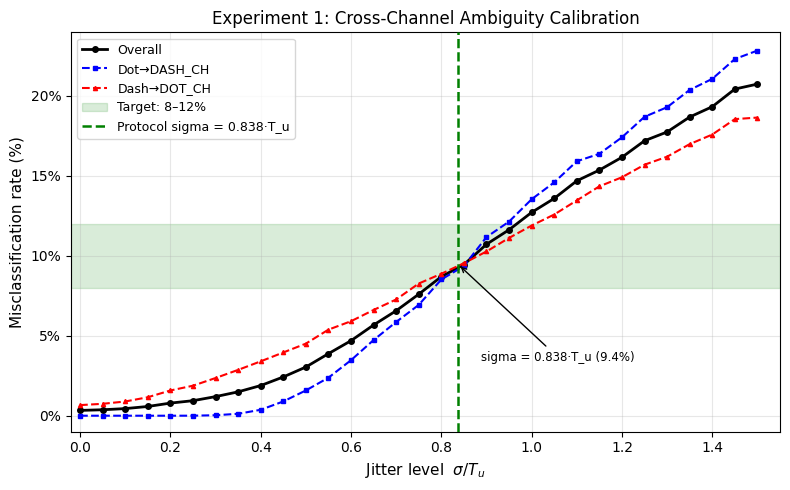

Saved → exp1_ambiguity_calibration.pdf


In [6]:
s_fracs   = np.array([r["sigma_frac"]        for r in sweep])
s_overall = np.array([r["overall_error_rate"] for r in sweep])
s_dot     = np.array([r["dot_error_rate"]     for r in sweep])
s_dash    = np.array([r["dash_error_rate"]    for r in sweep])

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(s_fracs, s_overall * 100, "k-o",  lw=2,   ms=4, label="Overall",     zorder=3)
ax.plot(s_fracs, s_dot     * 100, "b--s", lw=1.5, ms=3, label="Dot→DASH_CH", zorder=3)
ax.plot(s_fracs, s_dash    * 100, "r--^", lw=1.5, ms=3, label="Dash→DOT_CH", zorder=3)

ax.axhspan(CALIB_LO * 100, CALIB_HI * 100,
           alpha=0.15, color="green",
           label=f"Target: {CALIB_LO*100:.0f}–12%", zorder=1)

ax.axvline(SIGMA_FRAC, color="green", ls="--", lw=1.8, zorder=4,
           label=f"Protocol sigma = {SIGMA_FRAC}·T_u")
ax.annotate(
    f"sigma = {SIGMA_FRAC}·T_u ({overall*100:.1f}%)",
    xy=(SIGMA_FRAC, overall * 100),
    xytext=(SIGMA_FRAC + 0.05, overall * 100 - 6),
    fontsize=8.5, color="black",
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
)

ax.set_xlabel("Jitter level  $\sigma / T_u$", fontsize=11)
ax.set_ylabel("Misclassification rate (%)", fontsize=11)
ax.set_title("Experiment 1: Cross-Channel Ambiguity Calibration", fontsize=12)
ax.set_xlim(-0.02, s_fracs.max() + 0.05)
ax.set_ylim(-1, None)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("exp1_ambiguity_calibration.pdf", bbox_inches="tight")
plt.show()
print("Saved → exp1_ambiguity_calibration.pdf")

## Figure 2: Mark Duration Distributions at Protocol sigma

Shows how the dot and dash duration distributions sit relative to $T_{\text{thresh}}$
at the protocol noise level, illustrating the decision-boundary ambiguity.

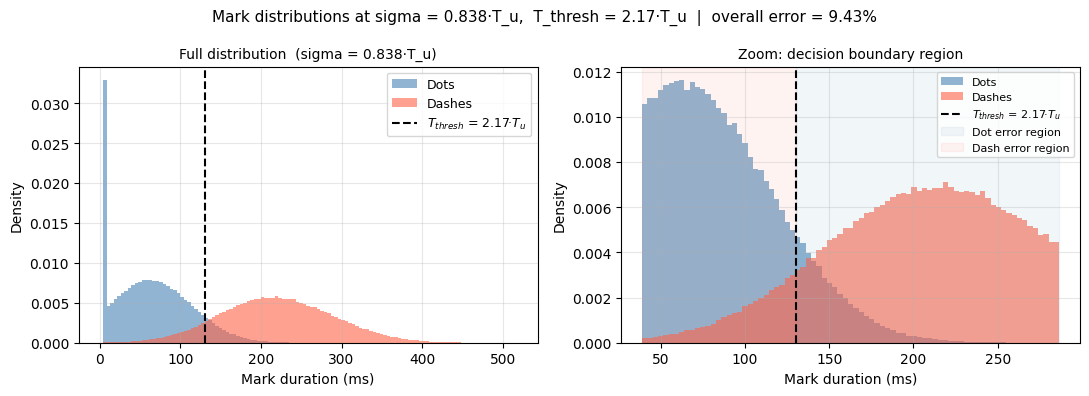

Saved → exp1_duration_distributions.pdf


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: full distribution
ax = axes[0]
bins = np.linspace(0, min(_dash_dur.max(), 10 * T_U), 120)
ax.hist(_dot_dur,  bins=bins, alpha=0.6, color="steelblue", label="Dots",   density=True)
ax.hist(_dash_dur, bins=bins, alpha=0.6, color="tomato",    label="Dashes", density=True)
ax.axvline(T_THRESH, color="black", ls="--", lw=1.5,
           label=f"$T_{{thresh}}$ = {T_THRESH/T_U:.2f}·$T_u$")
ax.set_xlabel("Mark duration (ms)", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title(f"Full distribution  (sigma = {SIGMA_FRAC}·T_u)", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: zoom around decision boundary
ax = axes[1]
zoom_lo   = T_THRESH * 0.3
zoom_hi   = T_THRESH * 2.2
mask_dot  = (_dot_dur  >= zoom_lo) & (_dot_dur  <= zoom_hi)
mask_dash = (_dash_dur >= zoom_lo) & (_dash_dur <= zoom_hi)
bins_zoom = np.linspace(zoom_lo, zoom_hi, 80)
ax.hist(_dot_dur[mask_dot],   bins=bins_zoom, alpha=0.6, color="steelblue", label="Dots",   density=True)
ax.hist(_dash_dur[mask_dash], bins=bins_zoom, alpha=0.6, color="tomato",    label="Dashes", density=True)
ax.axvline(T_THRESH, color="black", ls="--", lw=1.5,
           label=f"$T_{{thresh}}$ = {T_THRESH/T_U:.2f}·$T_u$")
ax.axvspan(T_THRESH, zoom_hi, alpha=0.07, color="steelblue", label="Dot error region")
ax.axvspan(zoom_lo, T_THRESH, alpha=0.07, color="tomato",    label="Dash error region")
ax.set_xlabel("Mark duration (ms)", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title("Zoom: decision boundary region", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Mark distributions at sigma = {SIGMA_FRAC}·T_u,  "
    f"T_thresh = {T_THRESH/T_U:.2f}·T_u  |  overall error = {overall*100:.2f}%",
    fontsize=11,
)
fig.tight_layout()
plt.savefig("exp1_duration_distributions.pdf", bbox_inches="tight")
plt.show()
print("Saved → exp1_duration_distributions.pdf")

## Summary

In [8]:
print("═" * 62)
print("Experiment 1 — Cross-Channel Ambiguity Calibration")
print("═" * 62)
print()
print("Protocol parameters:")
print(f"  WPM      = {WPM}")
print(f"  T_u      = {T_U:.1f} ms")
print(f"  T_thresh = {T_THRESH:.2f} ms  ({T_THRESH/T_U:.2f}·T_u)")
print(f"  sigma    = {SIGMA_FRAC * T_U:.2f} ms  ({SIGMA_FRAC:.3f}·T_u)")
print()
print(f"Verification  (N = {N_VERIFY:,} marks):")
print(f"  Dot  error : {dot_rate*100:.3f}%  [{dot_lo*100:.3f}%, {dot_hi*100:.3f}%] 95% CI")
print(f"  Dash error : {dash_rate*100:.3f}%  [{dash_lo*100:.3f}%, {dash_hi*100:.3f}%] 95% CI")
print(f"  Overall    : {overall*100:.3f}%  [{ov_lo*100:.3f}%, {ov_hi*100:.3f}%] 95% CI")
print()
print(f"  Dot/dash ratio : {ratio:.3f}  ({'balanced ✓' if balanced else 'imbalanced ✗'})")
print(f"  In 8–12% band  : {'YES ✓' if in_band else 'NO ✗'}")
print()
print("Clipping (pre-clip duration < 0.1·T_u):")
print(f"  Dot  clipped : {dot_clip_frac*100:.3f}%")
print(f"  Dash clipped : {dash_clip_frac*100:.3f}%")
print()
print("Figures saved to paper/figures/:")
print("  exp1_ambiguity_calibration.pdf")
print("  exp1_duration_distributions.pdf")

══════════════════════════════════════════════════════════════
Experiment 1 — Cross-Channel Ambiguity Calibration
══════════════════════════════════════════════════════════════

Protocol parameters:
  WPM      = 20
  T_u      = 60.0 ms
  T_thresh = 130.20 ms  (2.17·T_u)
  sigma    = 50.28 ms  (0.838·T_u)

Verification  (N = 500,000 marks):
  Dot  error : 9.455%  [9.341%, 9.570%] 95% CI
  Dash error : 9.412%  [9.298%, 9.527%] 95% CI
  Overall    : 9.433%  [9.353%, 9.515%] 95% CI

  Dot/dash ratio : 1.005  (balanced ✓)
  In 8–12% band  : YES ✓

Clipping (pre-clip duration < 0.1·T_u):
  Dot  clipped : 13.159%
  Dash clipped : 0.038%

Figures saved to paper/figures/:
  exp1_ambiguity_calibration.pdf
  exp1_duration_distributions.pdf
